<a href="https://colab.research.google.com/github/weagan/Vision-Transformer-ViT/blob/main/Basic_Vision_Transformer_(ViT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 792M/792M [00:22<00:00, 35.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 17.6MB/s]


Epoch 1: Loss 0.6994 | Val Acc 62.00%
Epoch 2: Loss 0.6795 | Val Acc 62.00%
Epoch 3: Loss 0.6748 | Val Acc 62.00%
Epoch 4: Loss 0.6796 | Val Acc 62.50%
Epoch 5: Loss 0.6613 | Val Acc 56.50%
Epoch 6: Loss 0.6283 | Val Acc 52.50%
Epoch 7: Loss 0.6241 | Val Acc 57.50%
Epoch 8: Loss 0.6173 | Val Acc 53.00%
Epoch 9: Loss 0.5983 | Val Acc 60.00%
Epoch 10: Loss 0.5962 | Val Acc 52.00%
Epoch 11: Loss 0.5491 | Val Acc 52.50%
Epoch 12: Loss 0.5428 | Val Acc 59.00%
Epoch 13: Loss 0.5495 | Val Acc 47.50%
Epoch 14: Loss 0.5094 | Val Acc 55.50%
Epoch 15: Loss 0.4850 | Val Acc 47.00%


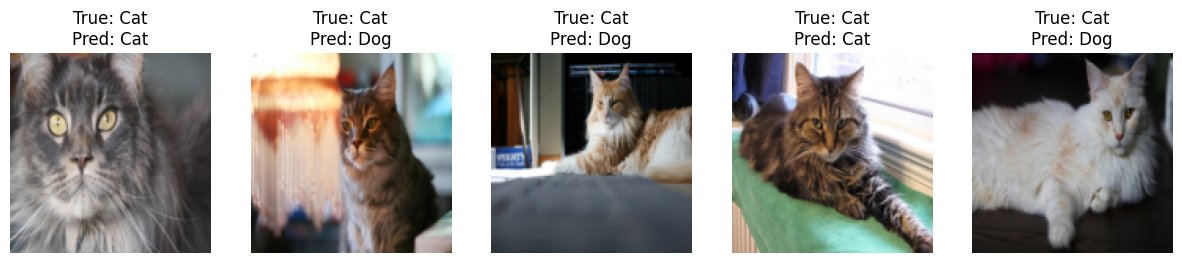

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. Setup & Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128
PATCH_SIZE = 16
D_MODEL = 128
MLP_DIM = 256
BATCH_SIZE = 32
EPOCHS = 15

# 2. Data Preparation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load and split: 80% Train, 20% Validation
full_dataset = datasets.OxfordIIITPet(root='./data', download=True, transform=transform)
subset_size = 1000 # Using 1000 images for better convergence
data_subset = Subset(full_dataset, range(subset_size))

train_size = int(0.8 * len(data_subset))
val_size = len(data_subset) - train_size
train_ds, val_ds = random_split(data_subset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# 3. The Minimalist ViT Model
class MinimalViT(nn.Module):
    def __init__(self):
        super().__init__()
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.patch_embed = nn.Linear(3 * PATCH_SIZE**2, D_MODEL)
        self.cls_token = nn.Parameter(torch.randn(1, 1, D_MODEL))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, D_MODEL))
        self.ln1 = nn.LayerNorm(D_MODEL)
        self.msa = nn.MultiheadAttention(D_MODEL, num_heads=1, batch_first=True)
        self.ln2 = nn.LayerNorm(D_MODEL)
        self.mlp = nn.Sequential(
            nn.Linear(D_MODEL, MLP_DIM),
            nn.GELU(),
            nn.Linear(MLP_DIM, D_MODEL)
        )
        self.head = nn.Linear(D_MODEL, 2)

    def forward(self, x):
        B = x.shape[0]
        # Patching
        x = x.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
        x = x.contiguous().view(B, 3, -1, PATCH_SIZE, PATCH_SIZE).permute(0, 2, 1, 3, 4).flatten(2)
        # Embedding
        x = self.patch_embed(x)
        x = torch.cat((self.cls_token.expand(B, -1, -1), x), dim=1) + self.pos_embed
        # Transformer Block (The Matrix Equation)
        attn_out, _ = self.msa(self.ln1(x), self.ln1(x), self.ln1(x))
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return self.head(x[:, 0])

def map_label(targets):
    """Maps breed IDs to 0 (Cat) or 1 (Dog)"""
    return torch.tensor([0 if 12 <= t <= 24 else 1 for t in targets.tolist()]).to(device)

# 4. Training Loop with Validation
model = MinimalViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), map_label(targets)
        optimizer.zero_grad()
        loss = criterion(model(imgs), targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_acc = 0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), map_label(targets)
            outputs = model(imgs)
            val_acc += (outputs.argmax(1) == targets).sum().item()

    print(f"Epoch {epoch+1}: Loss {train_loss/len(train_loader):.4f} | Val Acc {val_acc/val_size:.2%}")

# 5. Testing on Unseen Examples
def test_unseen(num_tests=5):
    model.eval()
    # Pull images from the very end of the dataset (totally unseen)
    test_indices = range(subset_size + 1, subset_size + 1 + num_tests)
    test_subset = Subset(full_dataset, test_indices)

    plt.figure(figsize=(15, 5))
    for i in range(num_tests):
        img_tensor, breed_id = test_subset[i]
        true_label = "Cat" if 12 <= breed_id <= 24 else "Dog"

        # Inference
        with torch.no_grad():
            output = model(img_tensor.unsqueeze(0).to(device))
            pred_idx = output.argmax(1).item()
            pred_label = "Cat" if pred_idx == 0 else "Dog"

        # Visualization
        plt.subplot(1, num_tests, i+1)
        plt.imshow(img_tensor.permute(1, 2, 0) * 0.5 + 0.5)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    plt.show()

test_unseen()

To create the ultimate single-matrix representation of your one-layer ViT, we nest the definitions of $\mathbf{Z}_0$ and $\mathbf{Z}'$ directly into the final output equation.

This expresses the entire transformation—from the raw image $x$ to the class prediction $y$—as a single continuous mathematical flow.

### The Unified ViT Matrix Equation

$$y = \text{Softmax} \left( \text{LN} \left( \sigma \left( \text{LN}(\mathbf{Z}') W_1 + b_1 \right) W_2 + b_2 + \mathbf{Z}' \right)_0 W_{head} \right)$$

where the intermediate Attention state $\mathbf{Z}'$ is defined as:

$$\mathbf{Z}' = \left( \text{Softmax} \left( \frac{(\text{LN}(\mathbf{Z}_0)W^Q)(\text{LN}(\mathbf{Z}_0)W^K)^\top}{\sqrt{D}} \right) (\text{LN}(\mathbf{Z}_0)W^V) W^O \right) + \mathbf{Z}_0$$

and the initial embedding state $\mathbf{Z}_0$ is defined as:

$$\mathbf{Z}_0 = [T'_{\text{cls}} \ || \ (f_{\text{patch}}(x) W_{\text{patch}})] + P_{\text{pos}}$$

---

### Variable Glossary & Dimensions

| Term | Component | Dimension | Description |
| --- | --- | --- | --- |
| $f_{\text{patch}}(x)$ | **Patching** | $N \times (P^2C)$ | The raw image $x$ flattened into $N$ patches. |
| $W_{\text{patch}}$ | **Projection** | $(P^2C) \times D$ | Learnable weights mapping patches to latent space. |
| $T'_{\text{cls}}$ | **Class Token** | $1 \times D$ | The learnable "summary" token prepended to the sequence. |
| $P_{\text{pos}}$ | **Position** | $(N+1) \times D$ | Spatial coordinates added to the sequence. |
| $\text{LN}$ | **Normalization** | $(N+1) \times D$ | Layer Normalization (mean=0, var=1) across $D$. |
| $W^Q, W^K, W^V$ | **Attention** | $D \times D$ | Weight matrices generating Queries, Keys, and Values. |
| $W^O$ | **Projection** | $D \times D$ | Linear projection of the attention-weighted values. |
| $W_1, W_2$ | **MLP** | $D \times 4D, 4D \times D$ | Feed-forward expansion and contraction weights. |
| $(\dots)_0$ | **Selection** | $1 \times D$ | Operation to extract only the first row (the CLS result). |
| $W_{head}$ | **Classification** | $D \times 2$ | Final mapping to Cat/Dog probability space. |

P stands for Patch size. It is used in the dimensions (P^2C) to represent the total number of pixels within a single square patch, considering C is the number of channels (e.g., 3 for RGB).
### Structural Logic

1. **Linearity vs Non-Linearity:** Notice that $\text{LN}$, $\text{Softmax}$, and $\sigma$ (GELU) are the only non-linear filters. Every other operation is a simple matrix multiplication or addition.
2. **The Residuals:** The "$+ \mathbf{Z}_0$" and "$+ \mathbf{Z}'$" terms are the "Skip Connections." They ensure the original signal persists even if the weights are initialized poorly, which is why your training starts from a baseline rather than complete chaos.
3. **The Logit Flow:** This equation essentially shows that a Transformer is a series of **weighted averages** (Attention) followed by **feature refinement** (MLP).



### Connecting ViT Matrix Equations to `MinimalViT` Python Code

Let's walk through the `MinimalViT`'s `forward` method and see how each step corresponds to the unified matrix equation components.

#### 1. Initial Embedding State (Derivation of $\mathbf{Z}_0$)

This section covers the transformation from the raw input image `x` to the initial embedded sequence $\mathbf{Z}_0$, ready for the Transformer block.

**Python Code:**
```python
def forward(self, x):
  '''x.shape[0] refers to the batch size of the input tensor x.When you pass a batch of images to the model,
   x is a tensor with dimensions (Batch Size, Channels, Height, Width).
    So, x.shape[0] will give you the number of images currently being processed in that batch.'''
    B = x.shape[0]
    # Patching
    x = x.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
    x = x.contiguous().view(B, 3, -1, PATCH_SIZE, PATCH_SIZE).permute(0, 2, 1, 3, 4).flatten(2)
    # Embedding
    x = self.patch_embed(x)
    x = torch.cat((self.cls_token.expand(B, -1, -1), x), dim=1) + self.pos_embed
```

**Corresponding Matrix Equation Steps:**

First, the image `x` is processed by the patching function $f_{\text{patch}}$:
$$X_{\text{flat}} = f_{\text{patch}}(x)$$
Then, these flattened patches are linearly projected by $W_{\text{patch}}$:
$$X_{\text{embed}} = X_{\text{flat}} W_{\text{patch}}$$
Next, the expanded class token $T'_{\text{cls}}$ is concatenated, and positional embeddings $P_{\text{pos}}$ are added to form $\mathbf{Z}_0$:
$$\mathbf{Z}_0 = [T'_{\text{cls}} \ || \ X_{\text{embed}}] + P_{\text{pos}}$$
**Resulting `x` (i.e., $\mathbf{Z}_0$) shape:** `(B, num_patches + 1, D_MODEL)`


#### 2. Attention State (Derivation of $\mathbf{Z}'$)

This section shows the self-attention mechanism, including Layer Normalization and the residual connection, leading to $\mathbf{Z}'$.

**Python Code:**
```python
    # Transformer Block (The Matrix Equation)
    attn_out, _ = self.msa(self.ln1(x), self.ln1(x), self.ln1(x))
    x = x + attn_out
```

**Corresponding Matrix Equation Steps:**

The input $\mathbf{Z}_0$ (represented by `x` here) is first Layer Normalized:
$$\text{LN}(\mathbf{Z}_0)$$
Then, the Multi-Head Self-Attention (`self.msa`) computes Queries, Keys, and Values using $W^Q, W^K, W^V$ from the normalized input, applies scaled dot-product attention, and projects the result with $W^O$. This produces the attention output which is then added back to the original $\mathbf{Z}_0$ (the `x` before `self.ln1`) via a residual connection to form $\mathbf{Z}'$:
$$\mathbf{Z}' = \left( \text{Softmax} \left( \frac{(\text{LN}(\mathbf{Z}_0)W^Q)(\text{LN}(\mathbf{Z}_0)W^K)^\top}{\sqrt{D}} \right) (\text{LN}(\mathbf{Z}_0)W^V) W^O \right) + \mathbf{Z}_0$$
**Resulting `x` (i.e., $\mathbf{Z}'$) shape:** `(B, num_patches + 1, D_MODEL)`

#### 3. MLP and Final Output (Derivation of $y$)

This section covers the Multi-Layer Perceptron (MLP) block and the final classification head.

**Python Code:**
```python
    x = x + self.mlp(self.ln2(x))
    return self.head(x[:, 0])
```

**Corresponding Matrix Equation Steps:**

First, $\mathbf{Z}'$ (the `x` from the previous step) is Layer Normalized:
$$\text{LN}(\mathbf{Z}')$$
This normalized output is then passed through the MLP block (composed of two linear layers with a GELU activation $\sigma$ and biases $b_1, b_2$), and another residual connection adds it back to $\mathbf{Z}'$:
$$\mathbf{Z}'' = \sigma (\text{LN}(\mathbf{Z}') W_1 + b_1) W_2 + b_2 + \mathbf{Z}'$$
Then, the output corresponding to the class token (the first element `[:, 0]`) is selected:
$$(\mathbf{Z}'')_0$$
Finally, this class token representation is passed through the classification head $W_{head}$ and a Softmax activation to get the final probabilities $y$:
$$y = \text{Softmax} \left( (\mathbf{Z}'')_0 W_{head} \right)$$
**Resulting `y` shape:** `(B, 2)` (for 2 classes: Cat/Dog)